Thinking...
Thinking...

reading metadata...

reading metadata...

reading metadata...

40T correction factor: 0.0014595727227983569
3T correction factor: 0.0006776303213032501

Plotting...


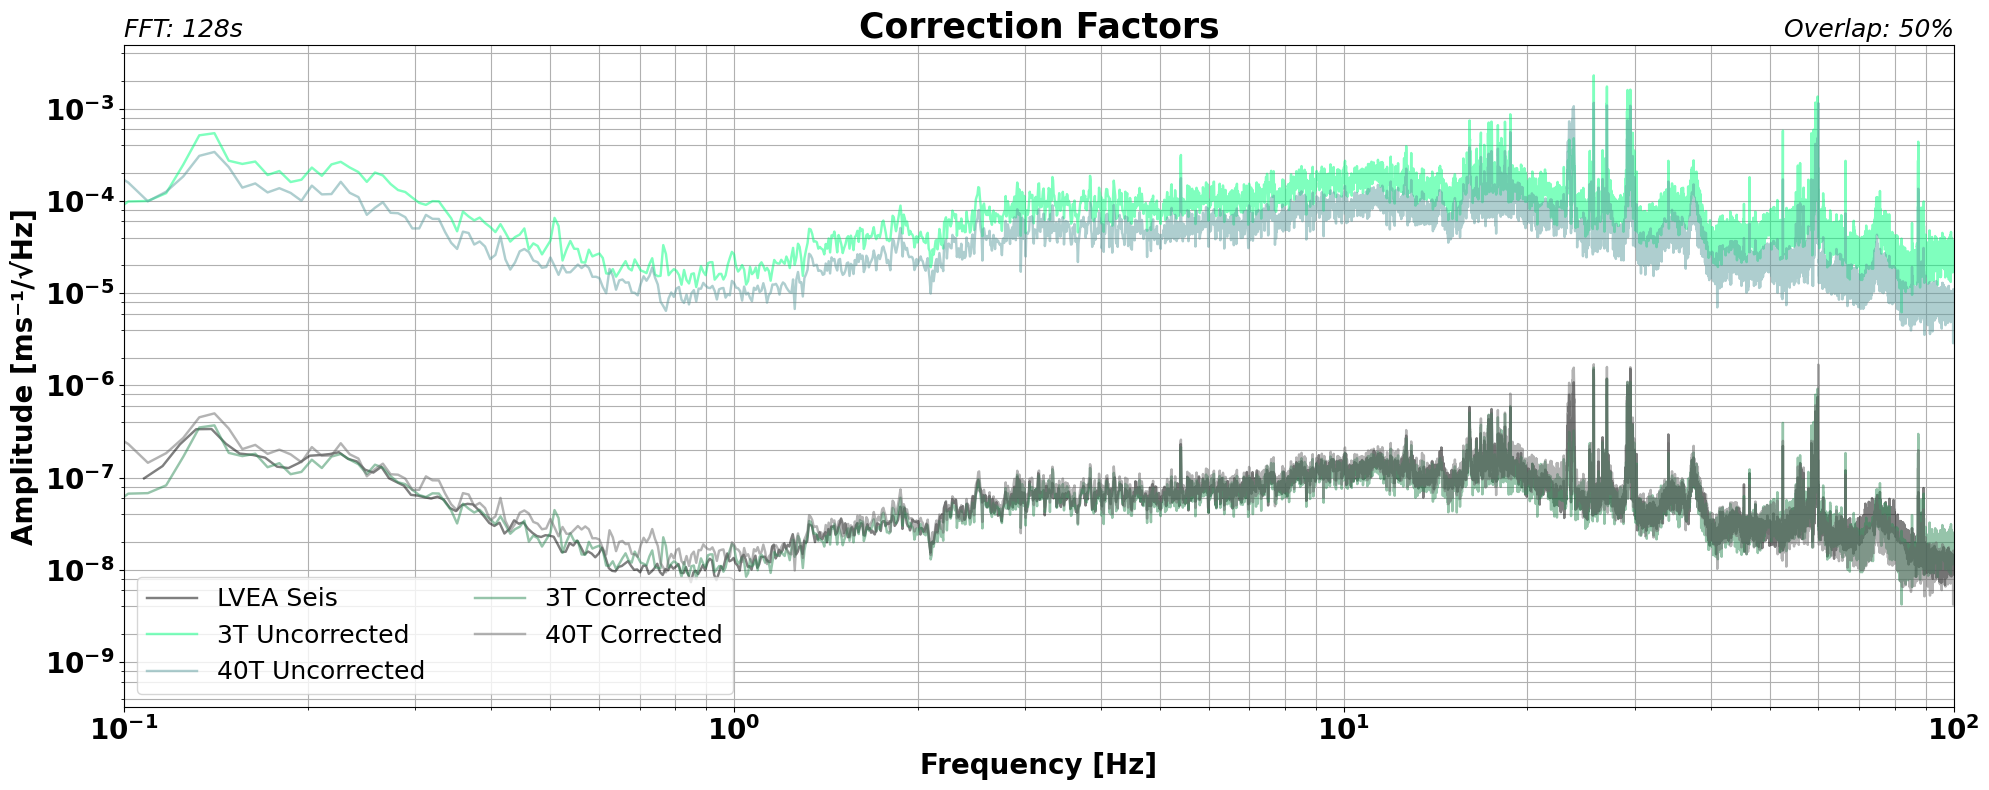

In [13]:
print("Thinking...")
import warnings
import pandas as pd                    # For reading CSV files into tables
import numpy as np                     # For numerical calculations
print("Thinking...\n")
from scipy import signal               # For the Welch PSD / spectral analysis
from matplotlib import pyplot as plt   # For creating plots
import matplotlib.ticker as ticker
import os

warnings.simplefilter('ignore')

###--------------------------------------------------------------------------------------------------------------------------###
'''------------------------------------------------- SECTION 1 — FILE PATH --------------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###
#                                                                                                                              #

kit_data = []
kit_data.append(r"C:\Users\cacam\Downloads\seis_2026-07-14T1329-1344.csv")
kit_data.append(r"C:\Users\cacam\Downloads\seis_2026-07-14T1348-1403.csv")
kit_data.append(r"C:\Users\cacam\Downloads\seis_2026-07-14T1411-1426.csv")


## ---------------------------------------------------- ##

Forty_T_First = False                                         # Set to True if pre-amps were active

## ---------------------------------------------------- ##


#                                                                                                                              #
## ------------------------------------------------------ LVEA Data --------------------------------------------------------- ##
#                                                                                                                              #

ligo_paths = []
ligo_paths.append(r"C:\Users\cacam\Downloads\huddle7-14_1329-1344.txt")
ligo_paths.append(r"C:\Users\cacam\Downloads\huddle7-14_1348-1403.txt")
ligo_paths.append(r"C:\Users\cacam\Downloads\huddle7-14_1411-1426.txt")

#                                                                                                                              #
###--------------------------------------------------------------------------------------------------------------------------###
'''----------------------------------------------- SECTION 2 — PLOT SETTINGS ------------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###
#                                                                                                                              #


## Y-axis (amplitude) range in m·s⁻¹/√Hz:
y_max = 10e-6
y_min = 10e-10 


## X-axis (frequency) range in Hz:
x_max = 100
x_min = 0.1 


## FFT (spectral analysis) settings:
fft_length = 128

## Precent FFT Overlap  [%]:
overlap    = 50


#                                                                                                                              #
###--------------------------------------------------------------------------------------------------------------------------###
'''---------------------------------------------- SECTION 3 — HUDDLE FUNCTION -----------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###


def huddle(case_data, sr, ligo):
    data = np.asarray(case_data)
    
    
    frequencies, power = signal.welch(
        
        data, 
        sr, 
        window    = 'hamming',
        nperseg   = int(sr * fft_length),
        noverlap  = int(round(sr * (overlap * 0.01)) ) 
    )
    
    amp = np.sqrt(power)
    
    calibration = ligo / amp[14:12802]
    calibration = np.median(calibration)
    
    return frequencies, amp, calibration


###--------------------------------------------------------------------------------------------------------------------------###
'''------------------------------------------------ SECTION 4 — READING DATA ------------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###


cali_factors_40T  = []
cali_factors_3T   = []

ligo_frequencies  = []
ligo_zeds         = []

frequencies_40T   = []
zeds_40T          = []

frequencies_3T    = []
zeds_3T           = []

i = 0
for i in range(len(kit_data)):
    
    ## -------------------------------------------------------- ##
    #                                                            #
    
    metadata = {}
    with open(kit_data[i], 'r') as f:
        for _ in range(5):
            line = f.readline().strip()
            if ':' in line:
                key, value = line.split(':', 1)
                metadata[key.strip()] = value.strip()

    print("reading metadata...\n")
    sample_rate = float(metadata["Sample Rate"])
    
    #                                                            #
    ## -------------------------------------------------------- ##
    #                                                            #
    
    seis = pd.read_csv(kit_data[i], skiprows = 5, delimiter = ',')
    
    if Forty_T_First == True:
        seis.columns = ["Sample", "Time (s)", 
                            "40T N", "40T Z", 
                            "3T N", "3T Z", 
                            "blank"]
    else:
        seis.columns = ["Sample", "Time (s)", 
                            "3T N", "3T Z", 
                            "40T N", "40T Z", 
                            "blank"]

    forty_t_n   = seis["40T N"]
    forty_t_z   = seis["40T Z"]

    three_t_n   = seis["3T N"]
    three_t_z   = seis["3T Z"] 
    
    #                                                            #
    ## -------------------------------------------------------- ##
    #                                                            #
    
    ligo_data = pd.read_csv(ligo_paths[i], delimiter = "\s+")

    ligo_data.columns = ["freq", "x", "y", "z"]

    cali = 0.0076e-6

    lvea_freq  = np.array(ligo_data["freq"])
    ligo_x     = ligo_data["x"] * cali
    ligo_y     = ligo_data["y"] * cali
    ligo_z     = ligo_data["z"] * cali
    
    #                                                            #
    ## -------------------------------------------------------- ##
    
    
    forty_z_freq, forty_z_amp, forty_z_cali = huddle(forty_t_z, sample_rate, ligo_z)
    
    three_z_freq, three_z_amp, three_z_cali = huddle(three_t_z, sample_rate, ligo_z)
    
    
    ## -------------------------------------------------------- ##
    #                                                            #
    
    cali_factors_40T.append(forty_z_cali)
    cali_factors_3T.append(three_z_cali)
    
    ligo_frequencies.append(lvea_freq)
    ligo_zeds.append(ligo_z)

    frequencies_40T.append(forty_z_freq)
    zeds_40T.append(forty_z_amp)

    frequencies_3T.append(three_z_freq)
    zeds_3T.append(three_z_amp)
    
    #                                                            #
    ## -------------------------------------------------------- ##
    
###--------------------------------------------------------------------------------------------------------------------------###
'''----------------------------------------------- SECTION 5 — PLOTTING DATA ------------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###

    
cali_factor_40T = np.median(cali_factors_40T)
cali_factor_3T = np.median(cali_factors_3T)

print("40T correction factor: " + str(cali_factor_40T))
print("3T correction factor: " + str(cali_factor_3T))


print("\nPlotting...")
plt.figure(1, figsize = (20, 8))  # one figure for all files

plt.plot(ligo_frequencies[0], ligo_zeds[0],
     color      = "black",
     linewidth  = 1.75,
     alpha      = 0.5,
     label      = "LVEA Seis")

plt.plot(frequencies_3T[0], zeds_3T[0],
         color      = "springgreen",
         linewidth  = 1.75,
         alpha      = 0.5,
         label      = "3T Uncorrected")

plt.plot(frequencies_40T[0], zeds_40T[0],
         color      = "cadetblue",
         linewidth  = 1.75,
         alpha      = 0.5,
         label      = "40T Uncorrected")

plt.plot(frequencies_3T[0], (zeds_3T[0] * cali_factor_3T),
         color      = "seagreen",
         linewidth  = 1.75,
         alpha      = 0.5,
         label      = "3T Corrected")

plt.plot(frequencies_40T[0], (zeds_40T[0] * cali_factors_40T[0]),
         color      = "dimgrey",
         linewidth  = 1.75,
         alpha      = 0.5,
         label      = "40T Corrected")


plt.yscale('log')
plt.xscale('log')

ax = plt.gca()
ax.minorticks_on()

plt.title("Correction Factors", fontweight = 'bold', fontsize = 25)
plt.title(f'FFT: {fft_length}s', fontsize = 18, loc = 'left', style = 'italic')
plt.title(f'Overlap: {overlap}%', fontsize = 18, loc = 'right', style = 'italic')

plt.xlabel('Frequency [Hz]', fontweight = 'bold', fontsize = 20)
plt.ylabel("Amplitude [ms⁻¹/√Hz]", fontweight = 'bold', fontsize = 20)

plt.yticks(fontsize = 20, fontweight = 'bold')
plt.xticks(fontsize = 20, fontweight = 'bold')


ax.tick_params(axis = 'both', which = 'minor', labelsize = 16)
for label in ax.get_yticklabels(which = 'minor'):
    label.set_fontweight('bold')

for label in ax.get_xticklabels(which = 'minor'):
    label.set_fontweight('bold')


ax.yaxis.set_major_locator(ticker.LogLocator(base     = 10.0, 
                                             numticks = 20))

ax.yaxis.set_minor_locator(ticker.LogLocator(base     = 10.0, 
                                             subs     = (0.2, 0.4, 0.6, 0.8), 
                                             numticks = 20))

plt.xlim(x_min, x_max)
#plt.ylim(y_min, y_max)

plt.legend(loc = 'lower left', fontsize = 18, ncol = 2)
plt.grid(True, which = 'both', ls = '-')
plt.tight_layout()
#plt.savefig("updated_factor.png")
plt.show()